# Final Data Report 

<b>Group Members</b>: Sean, Isabelle, Lily, Yogya 
<b>Group Number</b>: 19
<b>Group Name</b>: LI

## Introduction (Izzy)

### Predictive Question

<b>Question</b>: To what extent can a logistic regression model using both booking characteristics and customer behaviour accurately predict the probability of a hotel booking cancellation?

### Methods & Plans

### Packages

In [1]:
install.packages("tidymodels")
install.packages("mltools")
install.packages("leaps")
install.packages("pROC")
install.packages("skimr")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [39]:
library(MASS)
library(broom)
library(tidymodels)
library(repr)
library(leaps)
library(tidyverse)
library(modelr)
library(dplyr)
library(rsample)
library(car)
library(pROC)
library(patchwork)
library(caret)

Loading required package: lattice


Attaching package: ‘caret’


The following objects are masked from ‘package:yardstick’:

    precision, recall, sensitivity, specificity


The following object is masked from ‘package:rsample’:

    calibration


The following object is masked from ‘package:purrr’:

    lift




### Data

In [40]:
## Uncomment if csv was installed locally
## hotel_bookings <- read_csv('data/hotel_bookings.csv', show_col_types = FALSE) %>% select(-rownames)

url = "https://vincentarelbundock.github.io/Rdatasets/csv/bayesrules/hotel_bookings.csv"
hotel_bookings <- read_csv(url) %>% select(-rownames)

Rows: 1000 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): hotel, arrival_date_month, meal, country, market_segment, distrib...
dbl  (19): rownames, is_canceled, lead_time, arrival_date_year, arrival_date...
date  (1): reservation_status_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [41]:
n <- dim(hotel_bookings)[1]

variable_num <- dim(hotel_bookings)[2]

print(paste("Number of observations:", n))
print(paste("Number of variables:", variable_num))

[1] "Number of observations: 1000"
[1] "Number of variables: 32"


#### Data Source & Citations

The dataset was collected and compiled by Antonio, Almeida and Nunes (2019) and distributed through the R for Data Science TidyTuesday project. The dataset can be manually downloaded via accessing the following link: https://vincentarelbundock.github.io/Rdatasets/articles/data.html. 

This dataset is also part to the `bayesrules` R package which provides datasets and functions that summarize and plot Bayesian models found here: https://cran.r-project.org/web/packages/bayesrules/index.html

##### Citations

Nuno Antonio, Ana de Almeida, and Luis Nunes (2019). "Hotel booking demand datasets." Data in Brief (22): 41-49. https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/hotels.csv/.

Antonio, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. Data in Brief, 22, 41–49. https://doi.org/10.1016/j.dib.2018.11.126 



#### Information about Data

This data is observational and was obtained directly from the hotels’ Property Management System (PMS) SQL databases. Bookings were collected between the 1st of July of 2015 and the 31st of August 2017, including those that effectively arrived and bookings that were canceled. Because this is hotel real data, all data elements pertaining hotel or costumer identification were deleted by the authors (Antonio et al., 2019).

More information on the data collection for this dataset can be found here: https://www.sciencedirect.com/science/article/pii/S2352340918315191


#### Describing Variables

##### Data Types

In total, there are 32 variables in the dataset that are split into three types: `numeric` (18), `character` (13), and `date` (1). `rownames` was subtracted from the dataset, because it represents the index of hotel booking entries (not really important for EDA).

In [42]:
variable_info <- data.frame(Variable = names(hotel_bookings),
                            Type = sapply(hotel_bookings, class)) %>% select(Variable, Type)

freq_var_type <- variable_info %>% 
    group_by(Type) %>% 
    summarize(Frequency = n()) 

freq_var_type

Type,Frequency
<chr>,<int>
Date,1
character,13
numeric,18


##### Changing Data Types

Currently, categorical featues such as `is_canceled` and `is_repeated_guest` are treated currently as numerical features because they only contain boolean variables. In response to this issue, they need to be casted into categorical features.

In [43]:
hotel_bookings <- hotel_bookings %>%
    mutate(across(c(is_canceled, is_repeated_guest), as.factor))

##### Missing Values

The dataset denotes missing values as "NULL" for the categorical covariates. With this, only three variables contain missing variables: `company` (951 counts), `agent` (128 counts), and `country` (2 counts). 

In [44]:
cat_vars <- c("agent", "arrival_date_month", "assigned_room_type", "company", 
              "country", "customer_type", "deposit_type", "distribution_channel", 
              "is_canceled", "is_repeated_guest", "market_segment", "meal", 
              "reserved_room_type")

null_count_cat <- hotel_bookings %>% 
    select(all_of(cat_vars)) %>%
    summarise(across(everything(), ~sum(. == "NULL"))) %>%
    pivot_longer(everything(), names_to = "column_name", values_to = "null_count") %>%
    arrange(desc(null_count))

null_count_cat %>% filter(null_count > 0)

column_name,null_count
<chr>,<int>
company,951
agent,128
country,2


It can be assumed that the missing values in `company` and `agent` represent either guests who did not make a booking under a company or under an agent. These "NULL" values are to be transformed into the string value of "0". For country, these missing values represent that the guest's country of origin was not recorded (hence they will be removed before exploratory data analysis).

In [45]:
hotel_bookings <- hotel_bookings %>%
    mutate(agent = ifelse(agent == "NULL", 0, agent),
           company = ifelse(company == "NULL", 0, company))

There are no missing values for numerical or date variables.

In [46]:
dbl_vars <- c("lead_time", "arrival_date_year",
              "arrival_date_week_number", "arrival_date_day_of_month",
              "stays_in_weekend_nights", "stays_in_week_nights", "adults",
              "children", "babies", "previous_cancellations",
              "previous_bookings_not_canceled", "booking_changes",
              "days_in_waiting_list", "average_daily_rate",
              "required_car_parking_spaces", "total_of_special_requests")

null_count_dbl <- hotel_bookings %>% 
    select(all_of(dbl_vars)) %>%
    summarise(across(everything(), ~sum(is.na(.)))) %>%
    pivot_longer(everything(), names_to = "column_name", values_to = "null_count") %>%
    arrange(desc(null_count))

head(null_count_dbl)

null_count_date <- hotel_bookings %>%
    summarise(column_name = "reservation_status_date",
              null_count = sum(is.na(reservation_status_date))) %>%
    arrange(desc(null_count))

head(null_count_date)

column_name,null_count
<chr>,<int>
lead_time,0
arrival_date_year,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0


column_name,null_count
<chr>,<int>
reservation_status_date,0


##### Class Imbalance

There is evidence of class imbalance among categorical variables. For instance, majority of bookings are made under first-time guests and not part of a company. The target variable `is_canceled` is slightly imbalanced (not 50-50). 63.4% of bookings are not cancelled by customers, where as 36.6% is cancelled. 

In [47]:
class_imbalance <- hotel_bookings %>%
    select(all_of(cat_vars)) %>%
    pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
    count(variable, value) %>%
    group_by(variable) %>%
    mutate(percentage = n / sum(n) * 100) %>%
    filter(percentage > 50.0) %>%
    arrange(desc(percentage))

class_imbalance

variable,value,n,percentage
<chr>,<chr>,<int>,<dbl>
is_repeated_guest,0,968,96.8
company,0,951,95.1
deposit_type,No Deposit,881,88.1
distribution_channel,TA/TO,831,83.1
meal,BB,761,76.1
customer_type,Transient,742,74.2
reserved_room_type,A,722,72.2
is_canceled,0,634,63.4
assigned_room_type,A,620,62.0


### Exploratory Data Analysis (EDA)

#### Removing Explained Features

When loading the dataset, we also made the decision to remove some features because they may have little or detrimental effect to predicting cancellation:

- `rownames`: just an index identifier, carries no predictive information
- `reservation_status`: directly encodes whether a booking was cancelled (e.g. "Cancelled", "Check-Out"), making it a leaky variable that would perfectly predict the outcome
- `reservation_status_date`: the date the reservation status was last changed, also leaky for the same reason as above
- `arrival_date_week_number`: redundant with arrival_date_month which already captures seasonality
- `meal`: meal plan type is not directly related to cancellation behaviour and is not central to the research question
- `reserved_room_type`: the room type code is too granular and not meaningful for predicting cancellations
- `country`: too many unique values which would create too many dummy variables and reduce model stability
- `assigned_room_type`: the room actually assigned may differ from the reserved room, making it potentially leaky as it is determined at check-in
- `arrival_date_year`: not useful for prediction as we are not interested in year-specific trends
- `arrival_date_day_of_month`: too granular and unlikely to have a meaningful relationship with cancellations

In [48]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/bayesrules/hotel_bookings.csv"

#Removed features not relevant or detrimental to predicting is_canceled
hotel_bookings <- read_csv(url) %>% 
    dplyr::select(-rownames, 
                  -reservation_status, 
                  -reservation_status_date, 
                  -arrival_date_week_number, 
                  -meal, 
                  -reserved_room_type, 
                  -country,
                  -assigned_room_type,
                  -arrival_date_year,
                  -arrival_date_day_of_month)

Rows: 1000 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): hotel, arrival_date_month, meal, country, market_segment, distrib...
dbl  (19): rownames, is_canceled, lead_time, arrival_date_year, arrival_date...
date  (1): reservation_status_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


#### Cleaning Data

In [49]:
# Mutate agent and company features so no NA values
hotel_bookings <- hotel_bookings %>%
    mutate(agent = ifelse(agent == "NULL", 0, agent),
           company = ifelse(company == "NULL", 0, company))

# Make agent and company feature into a boolean feature
# The ID of the agent and company are not as important to predict is_canceled
# But whether the booking was made through an agent or company may be
# an indicator of cancellation behaviour

hotel_bookings <- hotel_bookings %>%
    mutate(agent = ifelse(agent > 0, 1, 0),
           company = ifelse(company > 0, 1, 0))

# Change char/string features into a factor feature (especially target)
hotel_bookings$customer_type <- as.factor(hotel_bookings$customer_type)
hotel_bookings$arrival_date_month <- as.factor(hotel_bookings$arrival_date_month)
hotel_bookings$hotel <- as.factor(hotel_bookings$hotel)
hotel_bookings$distribution_channel <- as.factor(hotel_bookings$distribution_channel)
hotel_bookings$is_repeated_guest <- as.integer(hotel_bookings$is_repeated_guest)
hotel_bookings$market_segment <- as.factor(hotel_bookings$market_segment)
hotel_bookings$agent <- as.integer(hotel_bookings$agent)
hotel_bookings$company <- as.integer(hotel_bookings$company)

# Change target feature into boolean 
hotel_bookings$is_canceled <- as.integer(hotel_bookings$is_canceled)

glimpse(hotel_bookings)

Rows: 1,000
Columns: 23
$ hotel                          <fct> City Hotel, Resort Hotel, Resort Hotel,…
$ is_canceled                    <int> 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, …
$ lead_time                      <dbl> 1, 19, 9, 110, 329, 212, 14, 58, 88, 37…
$ arrival_date_month             <fct> September, March, August, November, Jul…
$ stays_in_weekend_nights        <dbl> 0, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 1, …
$ stays_in_week_nights           <dbl> 2, 4, 4, 1, 2, 8, 0, 5, 3, 3, 1, 1, 1, …
$ adults                         <dbl> 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, …
$ children                       <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, …
$ babies                         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ market_segment                 <fct> Offline TA/TO, Online TA, Online TA, On…
$ distribution_channel           <fct> TA/TO, TA/TO, TA/TO, TA/TO, TA/TO, TA/T…
$ is_repeated_guest              <int> 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, …
$ previous_cance

#### Creating Training Split for EDA

It is important that we create a train-test split before performing data analysis, because we do not want test data to influence our decisions when deciding how we build our logistic regression model. The training set will be used to build the model and variable selection.The test set will be used to see how good our model is at prediction.

In [50]:
set.seed(301)

split <- initial_split(hotel_bookings, prop = 0.8, strata = is_canceled)
train <- training(split)
test <- testing(split)

In [51]:
train %>%
    count(is_canceled) %>%
    mutate(percentage = round(n / sum(n) * 100, 1))

is_canceled,n,percentage
<int>,<int>,<dbl>
0,507,63.5
1,292,36.5


In [52]:
dbl_vars <- c("lead_time","stays_in_weekend_nights", "stays_in_week_nights", "adults",
              "children", "babies", "previous_cancellations",
              "previous_bookings_not_canceled", "booking_changes",
              "days_in_waiting_list", "average_daily_rate",
              "required_car_parking_spaces", "total_of_special_requests")

summary_numeric_data <- train %>%
    select(all_of(dbl_vars)) %>%
    summary()


#### Visualizations

`geom_smooth()` using formula = 'y ~ x'


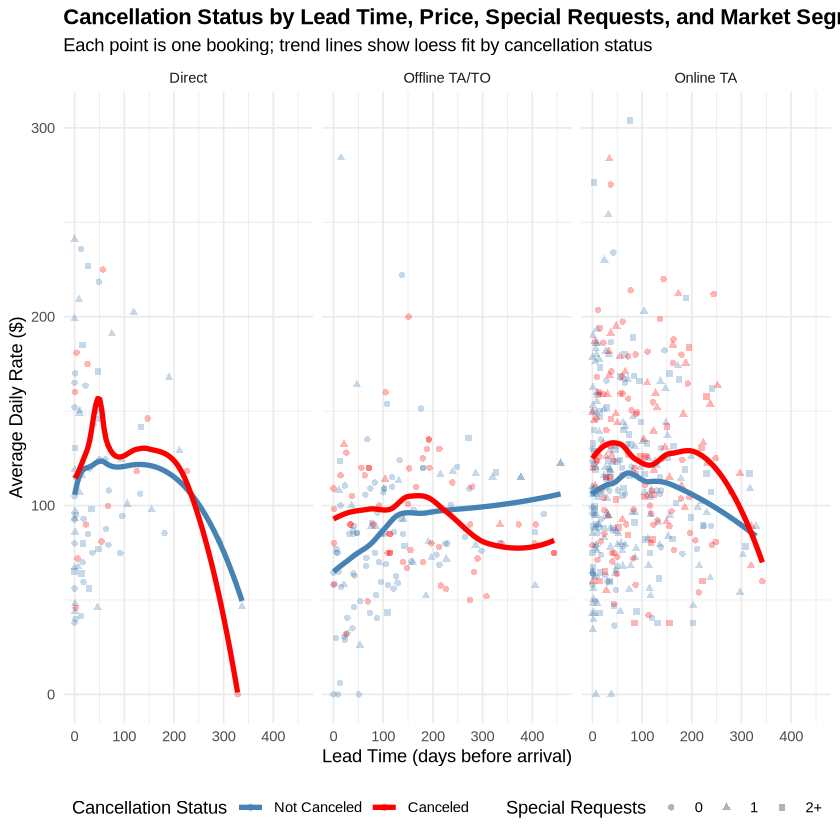

In [53]:
hotel_bookings_scatterplot <- train %>%
    mutate(
        special_requests_cat = case_when(
            total_of_special_requests == 0 ~ "0",
            total_of_special_requests == 1 ~ "1",
            TRUE ~ "2+"
        ),
        special_requests_cat = factor(special_requests_cat, levels = c("0", "1", "2+")),
        is_canceled = factor(is_canceled, levels = c(0, 1), labels = c("Not Canceled", "Canceled"))
    ) %>%
    filter(market_segment %in% c("Direct", "Offline TA/TO", "Online TA"))

# Plot
ggplot(hotel_bookings_scatterplot, aes(x = lead_time, y = average_daily_rate, color = is_canceled)) +
    geom_point(aes(shape = special_requests_cat), alpha = 0.3, size = 1.5) +
    geom_smooth(method = "loess", se = FALSE, linewidth = 1.5) +
    facet_wrap(~ market_segment) +
    scale_color_manual(
        name = "Cancellation Status",
        values = c("Not Canceled" = "steelblue", "Canceled" = "red")
    ) +
    scale_shape_manual(
        name = "Special Requests",
        values = c("0" = 16, "1" = 17, "2+" = 15)
    ) +
    labs(
        title = "Cancellation Status by Lead Time, Price, Special Requests, and Market Segment",
        subtitle = "Each point is one booking; trend lines show loess fit by cancellation status",
        x = "Lead Time (days before arrival)",
        y = "Average Daily Rate ($)"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(face = "bold"),
        legend.position = "bottom"
    )

This plot displays all 1,000 individual bookings and encodes five variables simultaneously: lead time (x-axis), average daily rate (y-axis), cancellation status (color), number of special requests (point shape), and market segment (facet). This makes it possible to visually assess whether cancellations cluster at particular combinations of price, booking horizon, and customer engagement.

Several patterns are visible. Across market segments, canceled bookings (red) tend to have longer lead times and are spread across all price levels, while bookings with two or more special requests (square points) appear more concentrated among non-canceled bookings, suggesting that more engaged customers are less likely to cancel. The plot is directly relevant to the research question because it simultaneously explores the relationships between the anticipated key covariates and the response variable across different customer segments.

These patterns suggest that both booking timing and customer engagement play an important role in cancellation behavior, which directly supports the goal of understanding how booking characteristics influence cancellations.

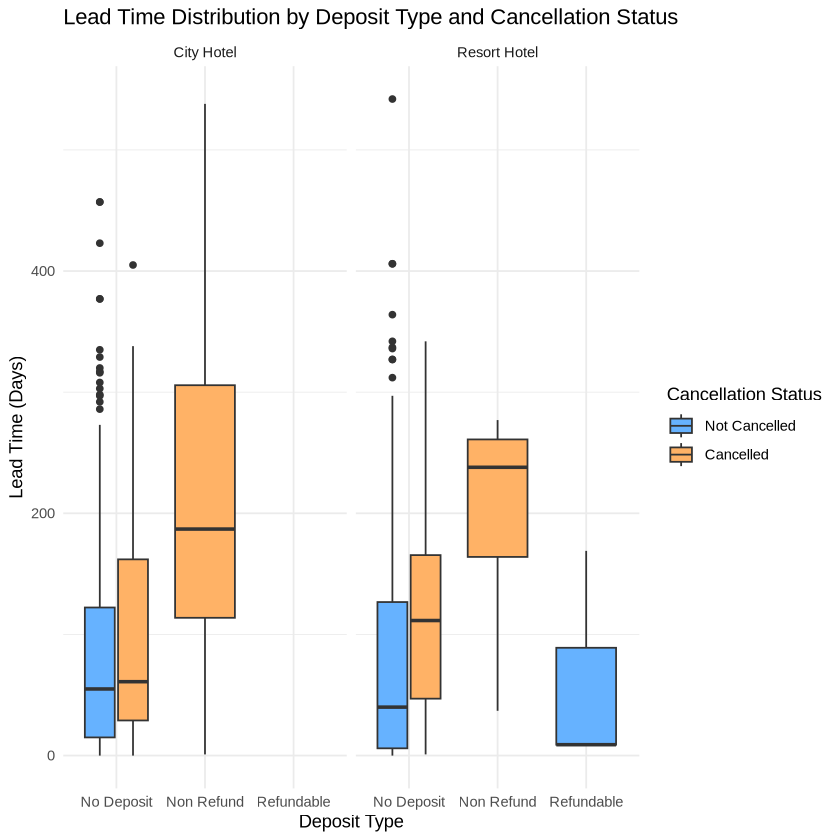

In [54]:
boxplot <- ggplot(train, aes(x = deposit_type, y = lead_time, fill = as.factor(is_canceled))) +
    geom_boxplot() +
    facet_wrap(~hotel) + 
    ggtitle("Lead Time Distribution by Deposit Type and Cancellation Status") +
    xlab("Deposit Type") +
    ylab("Lead Time (Days)") +
    scale_fill_manual(name = "Cancellation Status", values = c("#66B2FF", "#FFB266"), labels = c("Not Cancelled", "Cancelled")) +
    theme_minimal()

boxplot

This faceted boxplot incorporates four key variables: `hotel`, `deposit_type`, `lead_time`, and `is_canceled` (the target variable). By faceting on hotel type, it allows us to directly compare cancellation patterns between resort and city hotels, revealing whether the relationship between lead time and cancellation differs across environments.

For the No Deposit category, the relationship between lead time and cancellation differs between hotel types. In City Hotels, cancelled and non-cancelled bookings have similar median lead times with comparable right-skewed distributions, suggesting that lead time alone is not a strong differentiator of cancellation behaviour for this hotel type. In contrast, Resort Hotels show a clearer separation — cancelled bookings have a noticeably higher median lead time (approximately 100 days) compared to non-cancelled bookings (approximately 40 days), more strongly supporting the hypothesis that guests who book further in advance are more likely to cancel. This suggests that lead time may be a more informative predictor of cancellation for Resort Hotels than for City Hotels.

Another notable observation is that Non Refund deposit bookings appear to be almost exclusively cancelled, with virtually no "Not Cancelled" entries in either hotel type. Similarly, Refundable deposits in Resort Hotels appear to always result in non-cancellation. This near-perfect separation actually suggests that deposit_type is a highly informative predictor of cancellation behaviour: bookings made under a non-refundable policy are strongly associated with cancellation, while refundable bookings are not. This makes `deposit_type` a potentially valuable feature to retain in our model.

We then used a logistic regression model using is_cancelled as the response and the rest of the variables as the covariates. After checking for multicollinearity using the vif function, we reasoned that we could get rid of previous_cancellations and previous_bookings_not_canceled because the GVF was high.

In [55]:
lr_model1 <- glm(is_canceled ~ ., data = train, family = "binomial")

VIF_model <- vif(lr_model1)

round(VIF_model, 3)


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


,GVIF,Df,GVIF^(1/(2*Df))
hotel,1.144,1,1.069
lead_time,1.447,1,1.203
arrival_date_month,2.566,11,1.044
stays_in_weekend_nights,1.316,1,1.147
stays_in_week_nights,1.364,1,1.168
adults,1.231,1,1.110
children,1.204,1,1.097
babies,1.000,1,1.000
market_segment,90.229,5,1.569
distribution_channel,29.756,3,1.760


Next, we implemented stepAIC via backward selection. We did not pick LASSO because 13 variables in the dataset are categorical. If we were to use LASSO, that method could select part of a dummy variable but not the others. For example, with the variable, arrival_date_month, LASSO may select only January and February dummy variables but not the others. Using stepAIC resolves this issue as it looks at the variables all at once instead of separately. We selected backward over forward selection since the number of observations in the dataset is significantly larger than the number of variables (The dataset contains 1000 observations with 33 variables in total). From this, we determined that the best model to use was: 

is_canceled ~ lead_time + adults + children + babies + 
    market_segment + is_repeated_guest + booking_changes + deposit_type + 
    company + average_daily_rate + required_car_parking_spaces + 
    total_of_special_requests


In [56]:
lr_model <- glm(is_canceled ~ . - previous_bookings_not_canceled - previous_cancellations, data = train, family = "binomial")

# Had to use suppressWarnings function, otherwise there will be a long list of the warning message below
step_model <- suppressWarnings(stepAIC(lr_model, direction = "backward", trace = FALSE))

hotel_bookings_backward_summary <- summary(step_model)

hotel_bookings_backward_summary


Call:
glm(formula = is_canceled ~ lead_time + adults + children + babies + 
    market_segment + is_repeated_guest + booking_changes + deposit_type + 
    company + average_daily_rate + required_car_parking_spaces + 
    total_of_special_requests, family = "binomial", data = train)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -1.078e+00  1.268e+00  -0.850  0.39522    
lead_time                    4.655e-03  1.099e-03   4.237 2.27e-05 ***
adults                       5.243e-01  2.007e-01   2.612  0.00900 ** 
children                     4.498e-01  2.290e-01   1.965  0.04947 *  
babies                      -1.678e+01  2.193e+03  -0.008  0.99389    
market_segmentCorporate     -1.509e+00  1.450e+00  -1.040  0.29814    
market_segmentDirect        -2.129e+00  1.289e+00  -1.651  0.09864 .  
market_segmentGroups        -1.768e+00  1.273e+00  -1.389  0.16482    
market_segmentOffline TA/TO -2.412e+00  1.263e+00  -1.909  0.0

After model construction with the selected variables, we used a confusion matrix to evaluate classification performance, specifically precision and recall. To produce this confusion matrix, we used the product function on the test data using the above model.

In [57]:
hotel_formula <- formula(step_model)

hotel_lr_model <- glm(formula = hotel_formula,
                      data = train,
                      family = "binomial")

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


In [68]:
predictions <- predict(hotel_lr_model, newdata = test, type = "response")
predicted_class <- ifelse(predictions > 0.5, 1, 0)
confusion_matrix <- table(Predicted = predicted_class, Actual = test$is_canceled)
confusion_matrix

         Actual
Predicted   0   1
        0 112  32
        1  15  42

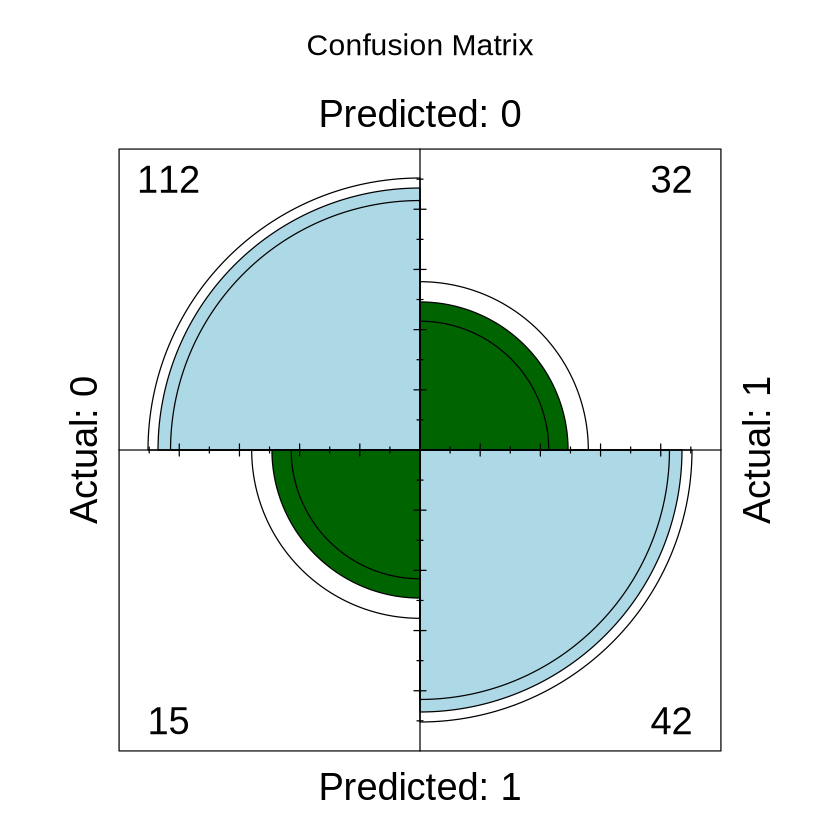

In [69]:
fourfoldplot(confusion_matrix,color=c("dark green","light blue"),main = "Confusion Matrix")

The above visualization can be interpreted as follows: each quadrant represents one of the four parts of the confusion matrix. The top left are the true negatives, the top right are the false negatives, the bottom left are the false positives, and the bottom right are the true positives. The area of the quadrant represents the frequency of that category.

The confusion matrix reveals that the model correctly classified 154 out of 201 bookings, yielding an overall accuracy of 76.6%. In terms of cancellation detection, the model achieved a precision of 73.4% ` = 42 / (42 + 15)` and a recall of 56.7% = `42 / (42 + 32)`, meaning that while it is reasonably accurate when it does predict a cancellation, it misses a portion of actual cancellations (32 false negatives). This suggests the model is more cautious in predicting cancellations, favouring non-cancellation predictions. In a hotel business context, these missed cancellations could be costly as they prevent the hotel from taking proactive measures to fill those rooms.